In [ ]:
from pathlib import Path
from collections import Counter
import os
import random
import numpy as np
import torch

PROJECT_DIR = Path.cwd()
SENSOR_DATA_DIR = PROJECT_DIR / "CREMA_D_Test"
OUTPUT_DIR = PROJECT_DIR / "Model_Output_CREMA_Retrained"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEVELOPMENT_ACTORS = ["1016", "1020", "1034", "1050"]
TEST_ACTORS = ["1067", "1087"]
CLASS_NAMES={
    0:"calm_speech",
    1:"distress",
}
CLASS_LABELS = {
    class_name: class_id
    for class_id, class_name in CLASS_NAMES.items()}

N_CLASSES = 2
SENSOR_SAMPLE_RATE = 8000

BANDPASS_LOW_HZ = 80
BANDPASS_HIGH_HZ = min(
    2000,
    int(SENSOR_SAMPLE_RATE * 0.45),
)

WINDOW_SEC = 3
HOP_SEC = 1.0
FEATURE_TYPE = "mfcc"

N_MFCC = 40
N_FFT = 512
HOP_LENGTH = 256
N_FEATURES = N_MFCC * 3 + 2

# Reproducibility and device
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
required_folders = ["calm_speech", "distress",]

for class_name in required_folders:
    class_folder = SENSOR_DATA_DIR / class_name
    if not class_folder.exists():
        raise FileNotFoundError(
            f"Missing class folder: {class_folder}"
        )

print("CREMA-D RETRAINING")
print(f"Dataset: {SENSOR_DATA_DIR}")
print(f"Output:  {OUTPUT_DIR}")
print(f"Device:  {DEVICE}")
print(f"Sample rate: {SENSOR_SAMPLE_RATE} Hz")
print(f"Window: {WINDOW_SEC} seconds")
print(f"Hop: {HOP_SEC} seconds")
print(f"Feature type: {FEATURE_TYPE}")

print("\nDevelopment actors:")
print(DEVELOPMENT_ACTORS)

print("\nUntouched test actors:")
print(TEST_ACTORS)
print("\nPrepared file counts:")

for class_name in required_folders:
    class_folder = SENSOR_DATA_DIR / class_name

    files = sorted(
        list(class_folder.glob("*.npy")) +
        list(class_folder.glob("*.wav"))
    )

    print(f"  {class_name:<13}: {len(files)} files")

print("\nSpeech files by actor:")
all_actor_ids = DEVELOPMENT_ACTORS + TEST_ACTORS

for actor_id in all_actor_ids:
    calm_files = list(
        (SENSOR_DATA_DIR / "calm_speech").glob(
            f"{actor_id}_*"
        )
    )

    distress_files = list(
        (SENSOR_DATA_DIR / "distress").glob(
            f"{actor_id}_*"
        )
    )

assert set(DEVELOPMENT_ACTORS).isdisjoint(TEST_ACTORS)

NameError: name 'ZIP_DIR' is not defined

In [41]:
!pip install -q librosa scikit-learn torch imbalanced-learn


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [42]:
import sys
print(sys.executable)
!{sys.executable} -m pip install librosa
import librosa
print(librosa.__version__)

/usr/local/bin/python3

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
0.11.0


In [ ]:
#imports
import os, glob, random, warnings, pickle
from pathlib import Path

import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, sosfilt, sosfiltfilt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")
random.seed(42);  np.random.seed(42);  torch.manual_seed(42)

In [ ]:
from pathlib import Path
import os
import torch

PROJECT_DIR = Path.cwd()
SENSOR_DATA_DIR = PROJECT_DIR / "CREMA_D_Test"
MODEL_DIR = PROJECT_DIR / "Model_Output_CREMA_Retrained"
OUTPUT_DIR = PROJECT_DIR / "CREMA_D_Inference_Output"

OUTPUT_DIR.mkdir(exist_ok=True)

SENSOR_SAMPLE_RATE = 8000
BANDPASS_LOW_HZ = 80
BANDPASS_HIGH_HZ = min(2000, int(SENSOR_SAMPLE_RATE * 0.45))

WINDOW_SEC = 3.0
HOP_SEC = 1.0
FEATURE_TYPE = "mfcc"

N_MFCC = 40
N_FFT = 512
HOP_LENGTH = 256
N_FEATURES = N_MFCC * 3 + 2

HIDDEN_SIZE = 64
NUM_LAYERS = 1
DROPOUT = 0.65
INPUT_DROPOUT = 0.30
BIDIRECTIONAL = True

CLASS_NAMES = {0: "calm_speech", 1: "distress"}
CLASS_LABELS = {v: k for k, v in CLASS_NAMES.items()}

N_CLASSES = len(CLASS_NAMES)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {DEVICE} | SR: {SENSOR_SAMPLE_RATE} | Features: {N_FEATURES}")
print(f"LSTM: hidden={HIDDEN_SIZE}, layers={NUM_LAYERS}, dropout={DROPOUT}, input_drop={INPUT_DROPOUT}, bidir={BIDIRECTIONAL}")
print(f"Window: {WINDOW_SEC}s | Hop: {HOP_SEC}s | Features: {FEATURE_TYPE}")

Device: cpu | SR: 7400 | Features: 122
LSTM: hidden=64, layers=1, dropout=0.65, input_drop=0.3, bidir=True
Reg: SpecAugment + raw-signal aug + mixup(α=0.6) + label_smooth(0.1) + WD=0.005
Schedule: 6-epoch warmup → cosine decay over 80 epochs, patience=20


In [ ]:
from scipy.fftpack import dct as _dct

CREMA_SAMPLE_RATE = 8000

def bandpass_filter(signal, sr, low_hz, high_hz):
    nyq = sr / 2.0
    low = max(low_hz / nyq, 1e-4)
    high = min(high_hz / nyq, 0.999)
    if low >= high:
        return signal
    sos = butter(4, [low, high], btype="band", output="sos")
    return sosfiltfilt(sos, signal.astype(np.float32))

def _zscore_norm(window):
    mu = float(np.mean(window))
    sigma = float(np.std(window))
    return (window - mu) / (sigma + 1e-8)

def extract_features(window, sr):
    window = window.astype(np.float32)
    window_norm = _zscore_norm(window)
    if FEATURE_TYPE == "mfcc":
        return _extract_mfcc(window_norm, window, sr)
    elif FEATURE_TYPE == "raw":
        return _extract_raw_frames(window_norm)
    else:
        raise ValueError(f"Unknown FEATURE_TYPE: {FEATURE_TYPE!r}")

def _extract_mfcc(window_norm, window_raw, sr):
    mfcc = librosa.feature.mfcc(
        y=window_norm,
        sr=sr,
        n_mfcc=N_MFCC,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
    )
    delta = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)
    zcr = librosa.feature.zero_crossing_rate(
        window_norm,
        frame_length=N_FFT,
        hop_length=HOP_LENGTH,
    )
    rms = librosa.feature.rms(
        y=window_raw,
        frame_length=N_FFT,
        hop_length=HOP_LENGTH,
    )
    return np.vstack([mfcc, delta, delta2, zcr, rms]).T

def _extract_raw_frames(window_norm):
    frames = [
        window_norm[s:s + N_FFT]
        for s in range(
            0,
            len(window_norm) - N_FFT + 1,
            HOP_LENGTH,
        )
    ]
    if not frames:
        return np.zeros((1, N_FFT), dtype=np.float32)
    return np.array(frames, dtype=np.float32)

def _n_features():
    if FEATURE_TYPE == "mfcc":
        return N_MFCC * 3 + 2
    elif FEATURE_TYPE == "raw":
        return N_FFT
    raise ValueError(f"Unknown FEATURE_TYPE: {FEATURE_TYPE!r}")

def segment_and_extract(signal, sr, label):
    signal = bandpass_filter(
        signal,
        sr,
        BANDPASS_LOW_HZ,
        BANDPASS_HIGH_HZ,
    )
    win_len = int(WINDOW_SEC * sr)
    hop_len = int(HOP_SEC * sr)
    samples = []
    for start in range(
        0,
        len(signal) - win_len + 1,
        hop_len,
    ):
        window = signal[start:start + win_len]
        features = extract_features(window, sr)
        if features.shape[0] > 0:
            samples.append((features, label))
    return samples

def load_one_file(fpath, sr):
    ext = Path(fpath).suffix.lower()
    if ext == ".npy":
        signal = np.load(fpath).astype(np.float32).ravel()
        if sr != CREMA_SAMPLE_RATE:
            signal = librosa.resample(
                signal,
                orig_sr=CREMA_SAMPLE_RATE,
                target_sr=sr,
            )
        return signal.astype(np.float32)
    signal, file_sr = librosa.load(
        fpath,
        sr=None,
        mono=True,
    )
    if file_sr != sr:
        signal = librosa.resample(
            signal,
            orig_sr=file_sr,
            target_sr=sr,
        )
    return signal.astype(np.float32)

In [ ]:
N_FEATURES = _n_features()

import csv as _csv_t
import os as _os_t

RESULTS_CSV = _os_t.path.join(OUTPUT_DIR, "experiment_results.csv")
_FIELDS = [
    "window_sec",
    "feature_type",
    "model",
    "macro_f1",
    "weighted_f1",
    "accuracy",
    "recall_calm_speech",
    "recall_distress",
    "n_test_windows",
    "notes",
]

def log_result(model_name, metrics_dict, notes=""):
    row = {
        "window_sec": WINDOW_SEC,
        "feature_type": FEATURE_TYPE,
        "model": model_name,
        "macro_f1": round(metrics_dict.get("macro_f1", 0), 4),
        "weighted_f1": round(metrics_dict.get("weighted_f1", 0), 4),
        "accuracy": round(metrics_dict.get("accuracy", 0), 4),
        "recall_calm_speech": round(metrics_dict.get("recall_calm_speech", 0), 4),
        "recall_distress": round(metrics_dict.get("recall_distress", 0), 4),
        "n_test_windows": len(X_test) if "X_test" in vars() else "",
        "notes": notes,
    }
    exists = _os_t.path.exists(RESULTS_CSV)
    with open(RESULTS_CSV, "a", newline="") as f:
        writer = _csv_t.DictWriter(f, fieldnames=_FIELDS)
        if not exists:
            writer.writeheader()
        writer.writerow(row)
    print(
        f"  [tracker] {model_name} | {WINDOW_SEC}s | {FEATURE_TYPE} "
        f"| macro_f1={row['macro_f1']:.4f} "
        f"| distress_recall={row['recall_distress']:.4f}"
    )

def _extract_metrics(result_dict):
    from sklearn.metrics import classification_report
    y_t = result_dict.get("y_true", [])
    y_p = result_dict.get("y_pred", [])
    if len(y_t) == 0:
        return {}
    rep = classification_report(
        y_t,
        y_p,
        output_dict=True,
        target_names=list(CLASS_NAMES.values()),
        zero_division=0,
    )
    return {
        "macro_f1": rep["macro avg"]["f1-score"],
        "weighted_f1": rep["weighted avg"]["f1-score"],
        "accuracy": rep["accuracy"],
        "recall_calm_speech": rep.get("calm_speech", {}).get("recall", 0),
        "recall_distress": rep.get("distress", {}).get("recall", 0),
    }

print("Experiment tracker ready.")
print(f"Results CSV: {RESULTS_CSV}")
print(
    f"Current config: WINDOW_SEC={WINDOW_SEC}s, "
    f"FEATURE_TYPE={FEATURE_TYPE!r}, N_FEATURES={N_FEATURES}"
)

Experiment tracker ready.
  Results CSV: /content/drive/MyDrive/Senior_Design/Model_Output/experiment_results.csv
  Current config: WINDOW_SEC=8.0s, FEATURE_TYPE='mfcc', N_FEATURES=122


In [ ]:
print("Testing dataset ready.")
for class_name in CLASS_NAMES.values():
    files = [
        f
        for f in list((SENSOR_DATA_DIR / class_name).glob("*.npy"))
        + list((SENSOR_DATA_DIR / class_name).glob("*.wav"))
        if f.stem.split("_")[0] in TEST_ACTORS
    ]
    print(f"  {class_name}: {len(files)} held-out files")

Loading raw dataset...
  Per-class file counts: {'background': 33, 'calm_speech': 47, 'distress': 47}

Filtering silent windows in non-background classes...
  VAD: bg-median RMS = 382.8720, threshold (factor=0.5) = 191.4360
  VAD: dropped 379/2373 windows (16.0%) as silence:
    background   : dropped 0, kept 601
    calm_speech  : dropped 218, kept 700
    distress     : dropped 161, kept 693

Augmenting dataset...
  Natural max class count: 700
  Top-up target (cap)    : 2000
  Top-up background: need 1399 more windows (SpecAugment)
  Top-up calm_speech: need 1300 more windows (SpecAugment)
  Top-up distress: need 1307 more windows (SpecAugment)
  Total after augmentation: 6000 windows
  background: 2000 windows
  calm_speech: 2000 windows
  distress: 2000 windows


In [ ]:
class VibrationDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        return self.X[i], self.y[i]

class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim, attn_dim=None):
        super().__init__()
        attn_dim = attn_dim or max(hidden_dim // 2, 16)
        self.W = nn.Linear(hidden_dim, attn_dim)
        self.v = nn.Linear(attn_dim, 1, bias=False)

    def forward(self, rnn_out):
        scores = self.v(torch.tanh(self.W(rnn_out))).squeeze(-1)
        weights = torch.softmax(scores, dim=-1)
        context = (weights.unsqueeze(-1) * rnn_out).sum(dim=1)
        return context, weights

class RNNClassifier(nn.Module):
    def __init__(
        self,
        n_features,
        hidden_size,
        num_layers,
        n_classes,
        dropout=0.4,
        bidirectional=True,
        input_dropout=0.10,
    ):
        super().__init__()
        self.dirs = 2 if bidirectional else 1
        feat_dim = hidden_size * self.dirs
        self.input_drop = nn.Dropout(p=input_dropout)
        self.rnn = nn.LSTM(
            n_features,
            hidden_size,
            num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )
        self.layer_norm = nn.LayerNorm(feat_dim)
        self.attention = BahdanauAttention(feat_dim)
        self.classifier = nn.Sequential(
            nn.Linear(feat_dim, hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, n_classes),
        )

    def forward(self, x):
        x = self.input_drop(x)
        rnn_out, _ = self.rnn(x)
        rnn_out = self.layer_norm(rnn_out)
        context, weights = self.attention(rnn_out)
        logits = self.classifier(context)
        return logits, weights

In [ ]:
def _mixup_batch(xb, yb, n_classes, alpha=MIXUP_ALPHA):
    """Mixup at the MFCC-feature-tensor level. Returns mixed inputs and a
    soft target distribution (B, C)."""
    if alpha <= 0:
        return xb, torch.nn.functional.one_hot(yb, n_classes).float()
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(xb.size(0), device=xb.device)
    mixed = lam * xb + (1.0 - lam) * xb[idx]
    y_onehot = torch.nn.functional.one_hot(yb, n_classes).float()
    y_mixed  = lam * y_onehot + (1.0 - lam) * y_onehot[idx]
    return mixed, y_mixed


def _soft_ce_loss(logits, soft_targets, label_smoothing=LABEL_SMOOTHING):
    """Cross-entropy against a (B, C) soft-label distribution + smoothing."""
    log_probs = torch.log_softmax(logits, dim=-1)
    if label_smoothing > 0:
        n_classes = logits.size(-1)
        soft_targets = soft_targets * (1.0 - label_smoothing) + label_smoothing / n_classes
    return -(soft_targets * log_probs).sum(dim=-1).mean()


def train_rnn(model: nn.Module, name: str, train_ld, val_ld,
              y_for_weights=None) -> dict:
    model = model.to(DEVICE)

    # Class-weighted CE for the eval-side criterion (mixup uses soft CE).
    y_w = y_for_weights if y_for_weights is not None else y_train
    class_counts = np.bincount(y_w, minlength=N_CLASSES)
    weights = torch.tensor(
        1.0 / (class_counts + 1e-6) * N_CLASSES / np.sum(1.0 / (class_counts + 1e-6)),
        dtype=torch.float32
    ).to(DEVICE)
    val_criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=LABEL_SMOOTHING)

    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE,
                            weight_decay=WEIGHT_DECAY)

    # Linear warmup → cosine decay scheduler.
    def lr_lambda(epoch):
        if epoch < WARMUP_EPOCHS:
            return (epoch + 1) / max(1, WARMUP_EPOCHS)
        progress = (epoch - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
        return 0.5 * (1.0 + np.cos(np.pi * min(progress, 1.0)))
    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

    history     = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_f1 = 0.0
    no_improve  = 0
    best_state  = None

    for epoch in range(1, EPOCHS + 1):
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for xb, yb in train_ld:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            # Mixup (no-op when alpha=0)
            xb_mix, y_soft = _mixup_batch(xb, yb, N_CLASSES, alpha=MIXUP_ALPHA)

            optimizer.zero_grad()
            logits, _ = model(xb_mix)
            loss = _soft_ce_loss(logits, y_soft, label_smoothing=LABEL_SMOOTHING)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            with torch.no_grad():
                # Track accuracy against the *original* hard labels for diagnostics.
                logits_eval, _ = model(xb)
                correct += (logits_eval.argmax(1) == yb).sum().item()
            total_loss += loss.item() * len(yb)
            total += len(yb)

        train_loss = total_loss / total
        train_acc  = correct / total

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        val_preds, val_true = [], []
        with torch.no_grad():
            for xb, yb in val_ld:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits, _ = model(xb)
                val_loss    += val_criterion(logits, yb).item() * len(yb)
                val_correct += (logits.argmax(1) == yb).sum().item()
                val_total   += len(yb)
                val_preds.extend(logits.argmax(1).cpu().numpy())
                val_true.extend(yb.cpu().numpy())

        val_loss /= val_total
        val_acc   = val_correct / val_total
        val_f1    = f1_score(val_true, val_preds, average="macro")

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        scheduler.step()

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, "lstm_attention.pth"))
            no_improve  = 0
        else:
            no_improve += 1

        if epoch % 5 == 0 or epoch == 1:
            print(f"  [{name}] Epoch {epoch:3d} | "
                  f"loss {train_loss:.4f}/{val_loss:.4f} | "
                  f"acc {train_acc:.4f}/{val_acc:.4f} | "
                  f"val_f1 {val_f1:.4f} | "
                  f"lr {optimizer.param_groups[0]['lr']:.2e}")

        if no_improve >= PATIENCE:
            print(f"  Early stop at epoch {epoch} (best val_f1={best_val_f1:.4f})")
            break

    model.load_state_dict(best_state)
    return {"model": model, "history": history, "best_val_f1": best_val_f1}


def evaluate_rnn(model: nn.Module, test_ld, name: str) -> dict:
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for xb, yb in test_ld:
            logits, _ = model(xb.to(DEVICE))
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_true.extend(yb.numpy())

    acc = accuracy_score(all_true, all_preds)
    f1m = f1_score(all_true, all_preds, average="macro")
    f1w = f1_score(all_true, all_preds, average="weighted")
    print(f"\n{name} -- Test Results")
    print(f"  Accuracy    : {acc:.4f}")
    print(f"  Macro F1    : {f1m:.4f}")
    print(f"  Weighted F1 : {f1w:.4f}")
    print(classification_report(all_true, all_preds,
                                 target_names=list(CLASS_NAMES.values())))
    return {"name": name, "accuracy": acc, "macro_f1": f1m,
            "weighted_f1": f1w, "y_pred": all_preds, "y_true": all_true}



  EVALUATION & PLOTS


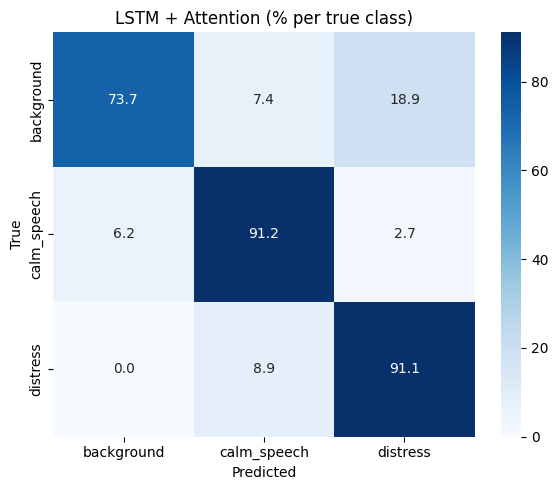

  Saved: /content/drive/MyDrive/Senior_Design/Model_Output/cm_lstm.png


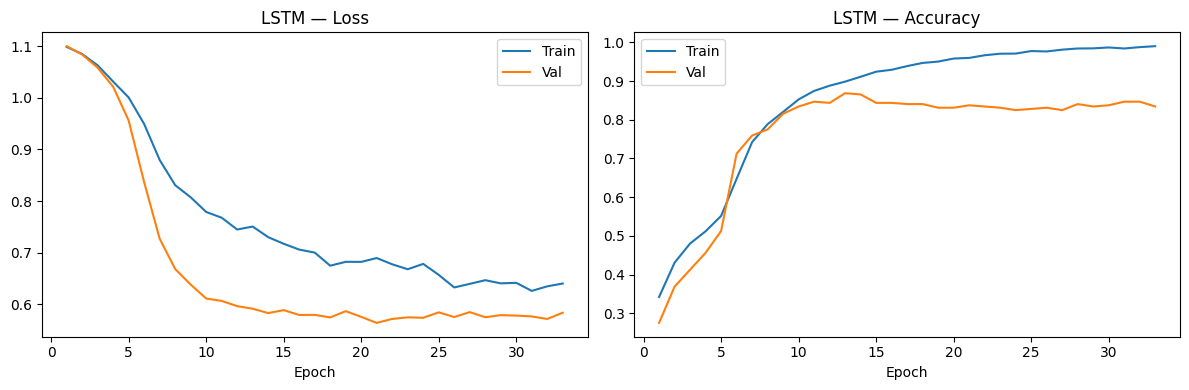

  Saved: /content/drive/MyDrive/Senior_Design/Model_Output/history_lstm.png

  MODEL COMPARISON SUMMARY
Model                      Accuracy  Macro F1  Weighted F1
------------------------------------------------------------
  Logistic Regression        0.7403    0.7419       0.7395
  Random Forest              0.8025    0.8049       0.7984
  SVM (RBF)                  0.7412    0.7413       0.7394
  LSTM + Attention (best CV fold)    0.7982    0.7928       0.7962
  LSTM + Attention (ensemble)    0.8614    0.8568       0.8597

  Results CSV: /content/drive/MyDrive/Senior_Design/Model_Output/model_comparison.csv
  LSTM model : /content/drive/MyDrive/Senior_Design/Model_Output/lstm_attention.pth
  Baselines  : /content/drive/MyDrive/Senior_Design/Model_Output/baseline_models.pkl

Done.


In [ ]:
# EVALUATION & VISUALISATION
def plot_confusion_matrix(y_true, y_pred, title: str, save_path: str):
    """Row-normalised confusion matrix (% per true class)."""
    cm     = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Blues",
                xticklabels=CLASS_NAMES.values(),
                yticklabels=CLASS_NAMES.values(), ax=ax)
    ax.set_title(f"{title} (% per true class)")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    plt.tight_layout(); plt.savefig(save_path, dpi=150); plt.show()
    print(f"  Saved: {save_path}")


def plot_training_history(history: dict, name: str, save_path: str):
    """Loss and accuracy curves over training epochs."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history["train_loss"]) + 1)

    ax1.plot(epochs, history["train_loss"], label="Train")
    ax1.plot(epochs, history["val_loss"],   label="Val")
    ax1.set_title(f"{name} — Loss"); ax1.set_xlabel("Epoch")
    ax1.legend()

    ax2.plot(epochs, history["train_acc"], label="Train")
    ax2.plot(epochs, history["val_acc"],   label="Val")
    ax2.set_title(f"{name} — Accuracy"); ax2.set_xlabel("Epoch")
    ax2.legend()

    plt.tight_layout()
    plt.savefig(save_path, dpi=150); plt.show()
    print(f"  Saved: {save_path}")


print("\n" + "="*60)
print("  EVALUATION & PLOTS")
print("="*60)

# Confusion matrix — LSTM
plot_confusion_matrix(
    lstm_result["y_true"], lstm_result["y_pred"],
    "LSTM + Attention",
    os.path.join(OUTPUT_DIR, "cm_lstm.png"))

# Training history curves — LSTM
plot_training_history(lstm_train["history"], "LSTM",
                      os.path.join(OUTPUT_DIR, "history_lstm.png"))

print("\n" + "="*60)
print("  MODEL COMPARISON SUMMARY")
print("="*60)
print(f"{'Model':<25} {'Accuracy':>9} {'Macro F1':>9} {'Weighted F1':>12}")
print("-" * 60)
for r in results:
    print(f"  {r['name']:<23} {r['accuracy']:>9.4f} {r['macro_f1']:>9.4f} "
          f"{r['weighted_f1']:>12.4f}")

# Save results to CSV
import csv as _csv_out
csv_path = os.path.join(OUTPUT_DIR, "model_comparison.csv")
with open(csv_path, "w", newline="") as f:
    writer = _csv_out.DictWriter(f, fieldnames=["name", "accuracy",
                                                  "macro_f1", "weighted_f1"])
    writer.writeheader()
    for r in results:
        writer.writerow({k: r[k] for k in ["name", "accuracy",
                                             "macro_f1", "weighted_f1"]})
print(f"\n  Results CSV: {csv_path}")
print(f"  LSTM model : {os.path.join(OUTPUT_DIR, 'lstm_attention.pth')}")
print(f"  Baselines  : {os.path.join(OUTPUT_DIR, 'baseline_models.pkl')}")
print("\nDone.")

In [49]:
# Testing only cell
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Model file not found: {MODEL_PATH}")

model = RNNClassifier(
    n_features=N_FEATURES,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    n_classes=N_CLASSES,
    dropout=DROPOUT,
    bidirectional=BIDIRECTIONAL,
    input_dropout=INPUT_DROPOUT,
).to(DEVICE)

checkpoint = torch.load(
    MODEL_PATH,
    map_location=DEVICE,
    weights_only=True,
)

model.load_state_dict(checkpoint)
model.eval()

print("Model loaded successfully!")
print(f"Loaded from: {MODEL_PATH}")
print(f"Device: {DEVICE}")

Model loaded successfully!
Loaded from: /Users/lizatinkujose/Documents/GitHub/IEEE-AIS-emotiondetection/Model_Output_RAVDESS/lstm_attention.pth
Device: cpu


In [50]:
# Testing only cell
import pickle
import numpy as np
import torch

SCALER_PATH = MODEL_DIR / "feat_scaler.pkl"
if not SCALER_PATH.exists():
    raise FileNotFoundError(
        f"Saved RAVDESS scaler not found: {SCALER_PATH}"
    )

with open(SCALER_PATH, "rb") as f:
    feat_scaler = pickle.load(f)
print(f"Scaler loaded from: {SCALER_PATH}")


def predict_crema_file(fpath):
    signal = load_one_file(
        fpath,
        SENSOR_SAMPLE_RATE,
    )
    signal = bandpass_filter(
        signal,
        SENSOR_SAMPLE_RATE,
        BANDPASS_LOW_HZ,
        BANDPASS_HIGH_HZ,
    )

    window_samples = int(WINDOW_SEC * SENSOR_SAMPLE_RATE)
    hop_samples = int(HOP_SEC * SENSOR_SAMPLE_RATE)

    if len(signal) < window_samples:
        signal = np.pad(
            signal,
            (0, window_samples - len(signal)),
            mode="constant",
        )
    starts = list(
        range(
            0,
            len(signal) - window_samples + 1,
            hop_samples,
        )
    )
    if not starts:
        starts = [0]
    final_start = len(signal) - window_samples
    if final_start >= 0 and final_start not in starts:
        starts.append(final_start)

    window_probabilities = []

    for start in starts:
        window = signal[start:start + window_samples]
        features = extract_features(
            window,
            SENSOR_SAMPLE_RATE,
        ).astype(np.float32)

        if features.ndim == 1:
            features = features.reshape(1, -1)

        if features.shape[1] != N_FEATURES:
            raise ValueError(
                f"{fpath.name}: extracted feature shape {features.shape}; "
                f"model expects {N_FEATURES} features per timestep."
            )
        features = feat_scaler.transform(features).astype(np.float32)

        x = torch.tensor(
            features,
            dtype=torch.float32,
        ).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            output = model(x)
            if isinstance(output, tuple):
                logits = output[0]
            else:
                logits = output

            probabilities = torch.softmax(logits, dim=1)

        window_probabilities.append(
            probabilities.squeeze(0).cpu().numpy()
        )
    mean_probabilities = np.mean(
        window_probabilities,
        axis=0,
    )

    predicted_label = int(np.argmax(mean_probabilities))
    return predicted_label, mean_probabilities, len(starts)

print("predict_crema_file() is ready.")

Scaler loaded from: /Users/lizatinkujose/Documents/GitHub/IEEE-AIS-emotiondetection/Model_Output_RAVDESS/feat_scaler.pkl
predict_crema_file() is ready.


In [51]:
# Testing only cell
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

true_label_folders = {
    "calm_speech": 1,
    "distress": 2,
}

y_true = []
y_pred = []
prediction_rows = []

for class_name, true_label in true_label_folders.items():
    folder = CREMA_TEST_DIR / class_name

    files = sorted(
        list(folder.glob("*.npy")) +
        list(folder.glob("*.wav"))
    )

    print(f"{class_name}: {len(files)} files")

    for fpath in files:
        try:
            pred_label, probs, n_windows = predict_crema_file(fpath)

            y_true.append(true_label)
            y_pred.append(pred_label)

            prediction_rows.append({
                "filename": fpath.name,
                "true_label": CLASS_NAMES[true_label],
                "predicted_label": CLASS_NAMES[pred_label],
                "prob_background": float(probs[0]),
                "prob_calm_speech": float(probs[1]),
                "prob_distress": float(probs[2]),
                "n_windows": n_windows,
                "correct": pred_label == true_label,
            })

        except Exception as e:
            print(f"Error processing {fpath.name}: {e}")

accuracy = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(
    y_true,
    y_pred,
    labels=[0, 1, 2],
    average="macro",
    zero_division=0,
)

weighted_f1 = f1_score(
    y_true,
    y_pred,
    labels=[0, 1, 2],
    average="weighted",
    zero_division=0,
)

print("CREMA-D TEST RESULTS")
print("=" * 60)

print(f"Files evaluated : {len(y_true)}")
print(f"Accuracy        : {accuracy:.4f}")
print(f"Macro F1        : {macro_f1:.4f}")
print(f"Weighted F1     : {weighted_f1:.4f}")

print("\nClassification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        labels=[0, 1, 2],
        target_names=[
            "background",
            "calm_speech",
            "distress",
        ],
        zero_division=0,
        digits=4,
    )
)
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0, 1, 2],
)

calm_speech: 36 files
distress: 126 files
CREMA-D TEST RESULTS
Files evaluated : 162
Accuracy        : 0.2222
Macro F1        : 0.1212
Weighted F1     : 0.0808

Classification Report:

              precision    recall  f1-score   support

  background     0.0000    0.0000    0.0000         0
 calm_speech     0.2222    1.0000    0.3636        36
    distress     0.0000    0.0000    0.0000       126

    accuracy                         0.2222       162
   macro avg     0.0741    0.3333    0.1212       162
weighted avg     0.0494    0.2222    0.0808       162

